\### SENTIMEN ANALISIS APLIKASI SHOPEE PADA GOOGLE PLAYSTORE

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import numpy as np
import pandas as pd
import re
import string
import nltk
import matplotlib.pyplot as plt
from sklearn.svm import SVC
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.datasets import load_files

# Read Data

In [3]:
review_nlp = pd.read_csv('/content/drive/MyDrive/Magang Hackative8/scrapped_data_shopeeee (1).csv')
review_nlp.head()

,content,score
0,Sangat membantu,5
1,Mantap,5
2,Apk yang tidak aman dan tidak mau bertanggung ...,1
3,Sangat membantu buat saya yg malas keluar rumah,5
4,Banyak bug error,2


In [4]:
review_nlp['score'].value_counts()

,count
score,
5,3466
1,726
4,414
2,206
3,188


# Labeling

In [5]:
label = []

for index, row in review_nlp.iterrows(): #Melakukan iterasi melalui setiap baris dalam DataFrame review_nlp
    if row['score'] >=4 :
        label.append(1) #label 1 untuk rating 4 keatas
    else :
        label.append(0) #label 0 untuk rating 3 sampai 1

review_nlp['label'] = label #list label yang telah diisi dengan nilai 0 dan 1
review_nlp = review_nlp.drop(columns=['score'])

review_nlp.head()

,content,label
0,Sangat membantu,1
1,Mantap,1
2,Apk yang tidak aman dan tidak mau bertanggung ...,0
3,Sangat membantu buat saya yg malas keluar rumah,1
4,Banyak bug error,0


In [6]:
review_nlp['label'].value_counts()
#label 1 575 ulasan positif
#label 0 221 ulasan negatif

,count
label,
1,3880
0,1120


# Mengatasi Data Tidak Seimbang

In [7]:
#oversampling
s1 = review_nlp[review_nlp['label']==1].sample(300, replace=True)
s2 = review_nlp[review_nlp['label']==0].sample(300, replace=True)
review_nlp = pd.concat([s1,s2])
print(review_nlp.shape)
print(review_nlp['label'].value_counts(normalize=True))
#kelas positif dan negatif seimbang masing2 130 sampel

(600, 2)
label
1    0.5
0    0.5
Name: proportion, dtype: float64


# Visualisasi Text

In [8]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

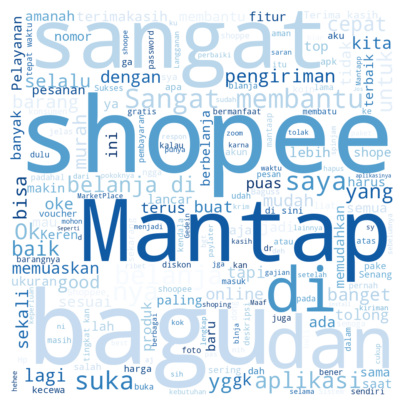

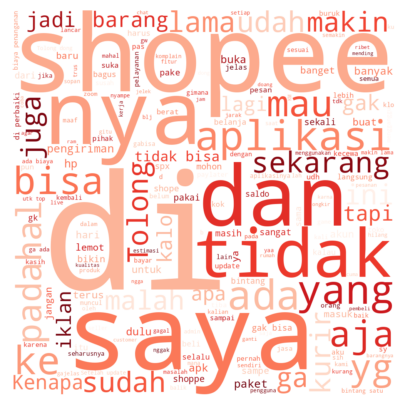

In [9]:
content_1 = review_nlp[review_nlp['label']==1]
content_1 = ' '.join(word for word in content_1['content'])
wcloud = WordCloud(colormap='Blues', width=1000, height=1000, mode= 'RGBA', background_color='white').generate(content_1)
plt.figure(figsize=(5, 5))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.show() #ulasan positif

content_0 = review_nlp[review_nlp['label']==0]
content_0 = ' '.join(word for word in content_0['content'])
wcloud = WordCloud(colormap='Reds', width=1000, height=1000, mode= 'RGBA', background_color='white').generate(content_0)
plt.figure(figsize=(5, 5))
plt.imshow(wcloud, interpolation='bilinear')
plt.axis('off')
plt.margins(x=0, y=0)
plt.show() #ulasan negatif

# Text Cleansing

In [10]:
def remove_unused(text):
    text = re.sub('[0-9]+', '', text) #menghapus angka dari text
    text = re.sub(r'\$\w*', '', text) #menghapus kata dimulai dari $
    text = re.sub(r'@[\w]*', '', text)#menghapus nama pengguna mulai dari @
    text = re.sub(r'https?://\S+', '', text)#menghapus url
    text = re.sub(r'#', '', text)
    text = re.sub(r'RT[\s]+', '', text)
    text = text.replace('\n', ' ')
    text = text.encode('ascii', 'ignore').decode('utf-8')
    text = re.sub(r'[^\x00-\x7f]', r'', text)
    text = re.sub(r'[^\w]', ' ', text)
    space = ['    ', '   ', '  ']
    for i in space:
        text = text.replace(i, ' ')
    text = text.lower().strip()
#     text = text.translate(str.maketrans('', '', string.punctuation))
    return text

In [11]:
review_nlp['clean text'] = review_nlp['content'].apply(lambda x: remove_unused(x))
review_nlp = review_nlp[['clean text', 'label']] #hasil dari clean text

In [12]:
review_nlp

,clean text,label
1424,selalu puas,1
655,aplikasi yg sangat bagus dan sangat membatu ap...,1
1886,sangat membantu,1
3543,bagus ngk pernah kecewa selama saya pesan di s...,1
1784,baguasss,1
...,...,...
2129,kualitas barangnya kurang bagus,0
631,kenapa sekarang ga ada menu buat save photo pi...,0
3243,notifikasi nya banyak bener dalam sehari bisa ...,0
958,spinjamnya ngk pernah acc kenapa,0


In [13]:
pip install sastrawi

In [14]:
#import stemmer
# memisahkan kata dalam tettxt
import nltk
from nltk.stem.snowball import SnowballStemmer
#the stemmer requires a language parameter
stemmer = SnowballStemmer(language='english')
#import stemmer
from Sastrawi.Stemmer.StemmerFactory import StemmerFactory
stemmer_id = StemmerFactory().create_stemmer()

In [15]:
import nltk

# Download the stopwords resource
nltk.download('stopwords')

# Now you can use the stopwords
from nltk.corpus import stopwords
stop_words = stopwords.words('english')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [16]:
# Instalasi pustaka
!pip install nltk

#import stopword
from Sastrawi.StopWordRemover.StopWordRemoverFactory import StopWordRemoverFactory
from nltk.corpus import stopwords
stopworder = set(stopwords.words('indonesian', 'english'))
stopword = StopWordRemoverFactory().create_stop_word_remover()
from nltk.tokenize import word_tokenize
tokenizer = word_tokenize


In [17]:
def cleansing(data):
    text = stemmer_id.stem(data)
    text = stopword.remove(text)
    text = tokenizer(text)
    text = [stemmer.stem(t) for t in text] #.split()]#stemmer inggris
    text = [word for word in text if word not in stopworder]
    text = ' '.join(word for word in text) # Menggabungkan kata-kata yang telah dibersihkan menjadi satu teks

    return text

In [18]:
# Contoh fungsi cleansing
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

# Unduh sumber daya 'stopwords' dan 'punkt'
nltk.download('stopwords')
nltk.download('punkt')


[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Package punkt is already up-to-date!


True

In [19]:
#contoh
import nltk
nltk.download('punkt_tab')

tes ='jika novel berteriak minta keadilan bagaimana'
cleaned = cleansing(tes)
print(cleaned)

novel teriak adil


[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


In [20]:
data_clean = review_nlp['clean text'].apply(cleansing)

In [21]:
data_clean

,clean text
1424,pua
655,aplikasi yg bagus batu spaylaternya mantap tin...
1886,bantu
3543,bagus ngk kecewa pesan shope gantung sih pesan...
1784,baguasss
...,...
2129,kualita barang bagus
631,ga menu save photo pict pdhl jual resel shope ...
3243,notifikasi nya bener an notifikasi
958,spinjamnya ngk acc


In [22]:
review_nlp['text'] = data_clean
data_nlp = review_nlp[['text', 'label']]

In [23]:
data_nlp.head()

,text,label
1424,pua,1
655,aplikasi yg bagus batu spaylaternya mantap tin...,1
1886,bantu,1
3543,bagus ngk kecewa pesan shope gantung sih pesan...,1
1784,baguasss,1


# Featur Enginering TF-IDF

 Fungsi ini menghitung bobot setiap kata dalam sebuah dokumen berdasarkan frekuensi kemunculan kata tersebut dalam dokumen dan seberapa jarang kata tersebut muncul di seluruh koleksi dokumen.

In [24]:
from sklearn.feature_extraction.text import TfidfVectorizer #mengukur kepentingan sebuah kata

In [25]:
vectorizer_tfidf = TfidfVectorizer() #inisialisasi

In [26]:
chat = ['halo apa kabar',
        'selamat bulan puasa',
        'lagi dimana',
        'how dinner eat'
       ]
chet = ['haha apa kabar',
        'selam bulan puasa',
        'lagi mana',
        'horse eat'
       ]

In [27]:
vectorized_tfidf = vectorizer_tfidf.fit_transform(chat)

In [28]:
vectorized_tfidf.shape

(4, 11)

In [29]:
#contoh feature
print(vectorized_tfidf.todense())

[[0.57735027 0.         0.         0.         0.         0.57735027
  0.         0.57735027 0.         0.         0.        ]
 [0.         0.57735027 0.         0.         0.         0.
  0.         0.         0.         0.57735027 0.57735027]
 [0.         0.         0.70710678 0.         0.         0.
  0.         0.         0.70710678 0.         0.        ]
 [0.         0.         0.         0.57735027 0.57735027 0.
  0.57735027 0.         0.         0.         0.        ]]


In [30]:
# Membuat TF-IDF Vectorizer
vectorizer_tfidf = TfidfVectorizer()

# Melakukan fit dan transformasi pada dokumen
X = vectorizer_tfidf.fit_transform(chat)

# Mendapatkan fitur nama menggunakan get_feature_names_out()
feature_names = vectorizer_tfidf.get_feature_names_out()
print(feature_names)

['apa' 'bulan' 'dimana' 'dinner' 'eat' 'halo' 'how' 'kabar' 'lagi' 'puasa'
 'selamat']


In [31]:
#implementasi pada text dan label
#train=pelatihan, teste=pengujian

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(review_nlp['text'], review_nlp['label'], test_size=0.1,
                                                  stratify = review_nlp['label'], random_state=30)

In [32]:
X_train = vectorizer_tfidf.fit_transform(X_train)
X_test = vectorizer_tfidf.transform(X_test)

print(X_train.shape)
print(X_test.shape)

(540, 1168)
(60, 1168)


# Modeling

In [33]:
from sklearn import svm
model_svm = svm.SVC(kernel='linear')

In [34]:
model_svm.fit(X_train, y_train)

,C,1.0
,kernel,'linear'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [35]:
pred = model_svm.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [37]:
accuracy = accuracy_score(y_test, pred)
print(f'accuracy : {accuracy}')

accuracy : 0.8833333333333333


In [38]:
clf_r = classification_report(y_test, pred)
print(clf_r)

              precision    recall  f1-score   support

           0       0.87      0.90      0.89        30
           1       0.90      0.87      0.88        30

    accuracy                           0.88        60
   macro avg       0.88      0.88      0.88        60
weighted avg       0.88      0.88      0.88        60



In [39]:
pip install --upgrade scikit-learn

# Simpan Model

In [40]:
import pickle
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split

# Contoh data
data = [
    "Saya sangat senang dengan produk ini",
    "Kualitasnya buruk sekali",
    "Pelayanan yang memuaskan",
    "Tidak puas dengan pembelian ini",
    "Produk ini luar biasa",
    "Sangat mengecewakan",
    # Tambahkan data lainnya
]
labels = [1, 0, 1, 0, 1, 0]  # 1 untuk positif, 0 untuk negatif

# Pisahkan data untuk pelatihan dan pengujian
X_train, X_test, y_train, y_test = train_test_split(data, labels, test_size=0.2, random_state=42)

# Buat vectorizer dan transformasikan data
vectorizer = TfidfVectorizer()
X_train_vectorized = vectorizer.fit_transform(X_train)

# Buat model dan latih
model = SVC()
model.fit(X_train_vectorized, y_train)

# Simpan model dan vectorizer
with open('sentiment_model.pkl', 'wb') as model_file:
    pickle.dump(model, model_file)

with open('vectorizer.pkl', 'wb') as vectorizer_file:
    pickle.dump(vectorizer, vectorizer_file)


# Prediksi

In [41]:
label = {1 : 'good', 0 : 'bad'}
print(label)

{1: 'good', 0: 'bad'}


In [42]:
text_good = 'sangat bagus, aplikasi mudah membantu, suka berguna'
text_bad = 'susah jelek, tidak berguna, buruk kecewa, sulit dipakai lambat banyak iklan'

# Cleansing

In [43]:
import re

# Fungsi pembersihan teks
def cleansing(text):
    # Menghapus spasi ganda
    text = re.sub(r'\s+', ' ', text)

    # Menghapus angka (jika diperlukan)
    text = re.sub(r'\d+', '', text)

    # Menghapus tanda baca
    text = re.sub(r'[^\w\s]', '', text)

    # Mengubah semua huruf menjadi kecil
    text = text.lower()

    return text

# Contoh penggunaan fungsi
text_bad = "saya tidak suka apikasi ini"
text_clean = remove_unused(text_bad)
print(f"Teks setelah remove_unused: {text_clean}")

# Setelah itu, jalankan cleansing
text_clean = cleansing(text_clean)
print(f"Teks setelah cleansing: {text_clean}")

Teks setelah remove_unused: saya tidak suka apikasi ini
Teks setelah cleansing: saya tidak suka apikasi ini


In [44]:
text_clean = remove_unused(text_bad)
print(text_clean)
text_clean = cleansing (text_clean)
print(text_clean)

saya tidak suka apikasi ini
saya tidak suka apikasi ini


# **contoh prediksi**

In [45]:
# Data pelatihan dan label
text_data = ["Sangat mengecewakan", "Luar biasa", "Buruk sekali", "Saya suka sekali", "Sangat bagus", "saya tidak suka apikasi ini"]
labels = [0, 1, 0, 1, 1, 0]

# Vektorisasi teks menggunakan TfidfVectorizer
vectorizer_tfidf = TfidfVectorizer()
X = vectorizer_tfidf.fit_transform(text_data)  # Ubah teks menjadi vektor

# Membagi data menjadi data pelatihan dan pengujian
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, labels, test_size=0.2, random_state=42)

# Melatih model SVM
from sklearn.svm import SVC
model_svm = SVC(kernel='linear')  # Menggunakan kernel linear
model_svm.fit(X_train, y_train)  # Melatih model dengan data pelatihan

# Teks yang akan diprediksi
new_text = ["saya tidak suka apikasi ini"]

# Vektorisasi teks baru (gunakan transform() pada teks baru)
new_text_vectorized = vectorizer_tfidf.transform(new_text)

# Prediksi dengan model yang telah dilatih
prediksi = model_svm.predict(new_text_vectorized)

# Menampilkan hasil prediksi
label = ['Negatif', 'Positif']  # Misalnya, label untuk kategori
i = prediksi[0]  # Ambil hasil prediksi
lab = label[i]
hasil = f'Merupakan text: {lab}'
print(hasil)


Merupakan text: Negatif
